Step 1: Generate Synthetic Data and Split It
We'll create:

Linearly Separable (LS) dataset: Three well-separated clusters.
Nonlinearly Separable (NLS) dataset: Overlapping clusters, making classification harder.

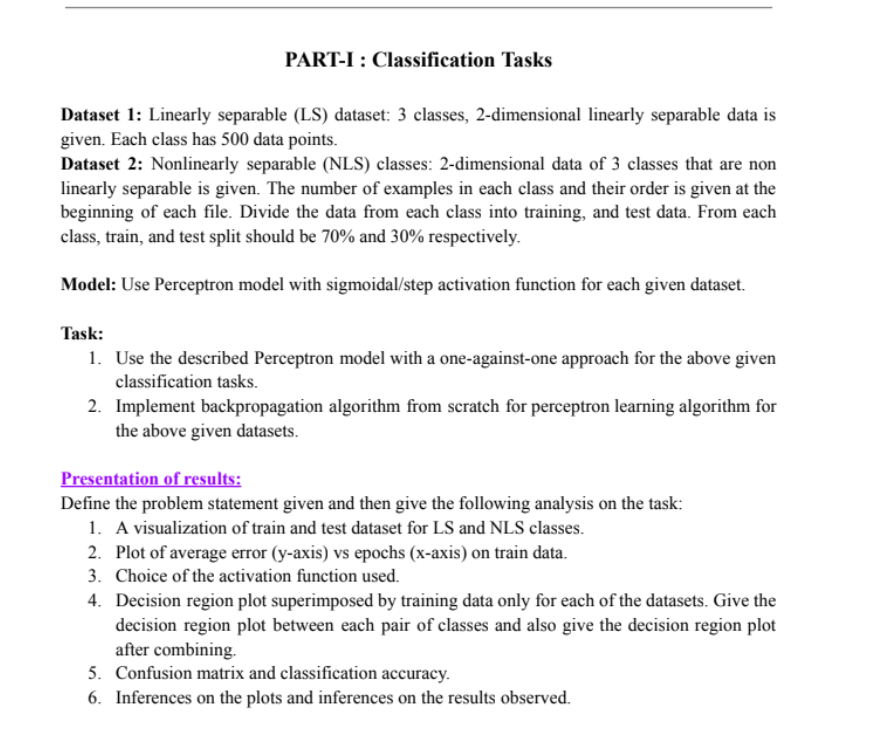

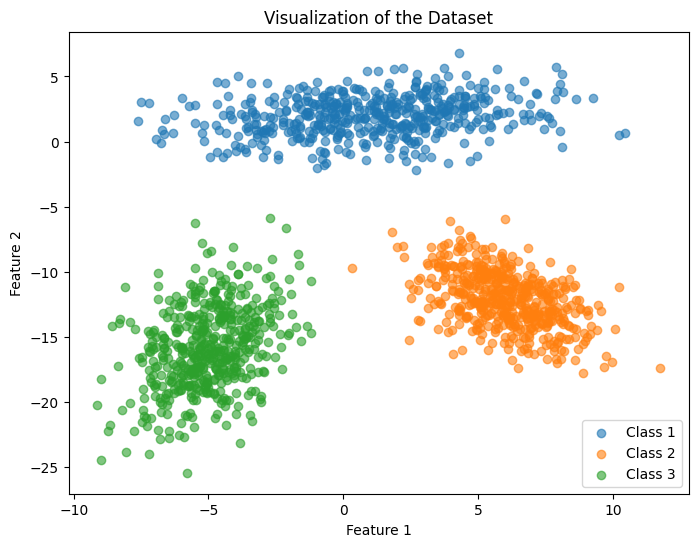

🔹 Model Accuracy: 99.78%
🔹 Confusion Matrix:
[[149   1   0]
 [  0 150   0]
 [  0   0 150]]


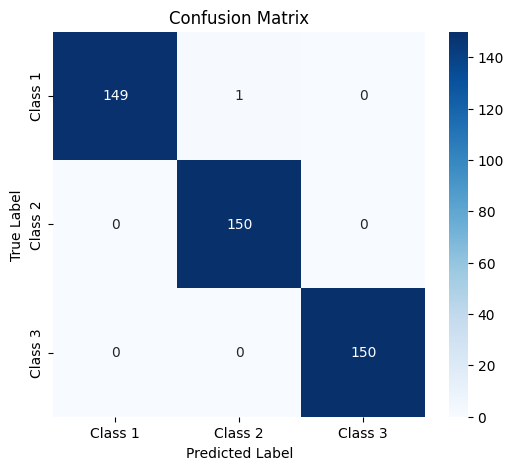

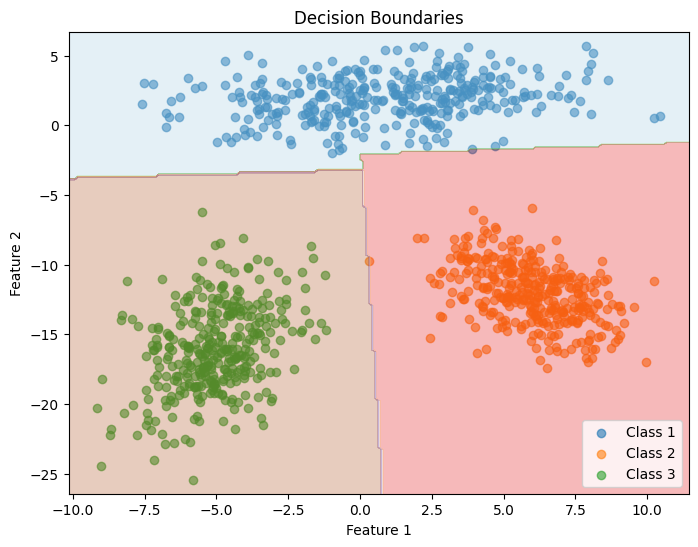

<ipython-input-13-975a82fed1b4>:142: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


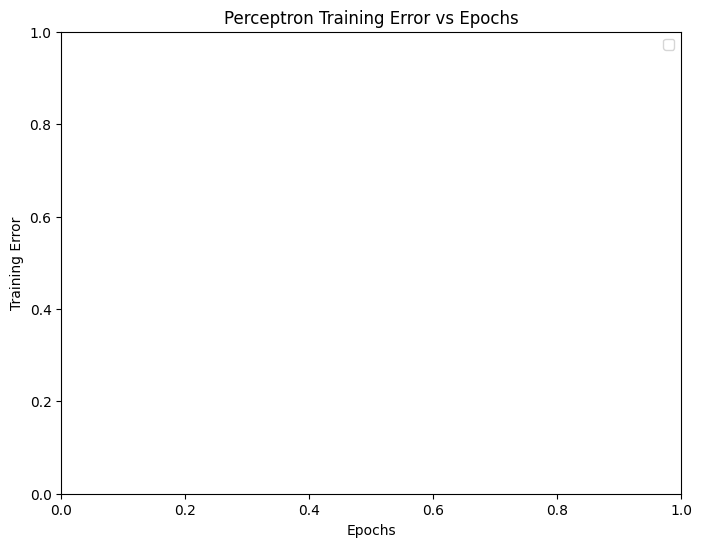

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix
from itertools import combinations

# Function to load dataset
def load_data(file_path, label):
    data = np.loadtxt(file_path)
    labels = np.full((data.shape[0], 1), label)  # Assign class label
    return np.hstack((data, labels))  # Combine features and labels

# Load class data
class1 = load_data("/content/drive/MyDrive/Class1.txt", label=0)
class2 = load_data("/content/drive/MyDrive/Class2.txt", label=1)
class3 = load_data("/content/drive/MyDrive/Class3.txt", label=2)

# Combine dataset
dataset = np.vstack((class1, class2, class3))

# Splitting into training (70%) and testing (30%) sets
X = dataset[:, :-1]  # Features (2D points)
y = dataset[:, -1]   # Labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 🎨 Plot the dataset
plt.figure(figsize=(8,6))
plt.scatter(class1[:, 0], class1[:, 1], label="Class 1", alpha=0.6)
plt.scatter(class2[:, 0], class2[:, 1], label="Class 2", alpha=0.6)
plt.scatter(class3[:, 0], class3[:, 1], label="Class 3", alpha=0.6)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Visualization of the Dataset")
plt.legend()
plt.show()

# 🔥 One-vs-One Perceptron training
classifiers = {}
pairwise_combinations = list(combinations(np.unique(y), 2))

for (class_a, class_b) in pairwise_combinations:
    idx = (y_train == class_a) | (y_train == class_b)
    X_binary, y_binary = X_train[idx], y_train[idx]
    y_binary = np.where(y_binary == class_a, -1, 1)  # Convert labels to {-1, 1}

    # Train Perceptron model
    perceptron = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
    perceptron.fit(X_binary, y_binary)
    classifiers[(class_a, class_b)] = perceptron

# 🎯 Evaluating the model
y_pred = np.zeros(y_test.shape)

for i, x in enumerate(X_test):
    votes = {cls: 0 for cls in np.unique(y)}

    for (class_a, class_b), clf in classifiers.items():
        prediction = clf.predict([x])[0]
        winner = class_a if prediction == -1 else class_b
        votes[winner] += 1

    y_pred[i] = max(votes, key=votes.get)

# 📊 Performance metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"🔹 Model Accuracy: {accuracy * 100:.2f}%")
print("🔹 Confusion Matrix:")
print(conf_matrix)

# 🎨 Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 1", "Class 2", "Class 3"], yticklabels=["Class 1", "Class 2", "Class 3"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 🏆 Plot decision boundaries
def plot_decision_boundary(classifiers, X, y):
    plt.figure(figsize=(8, 6))

    # Scatter plot of data points
    for class_label in np.unique(y):
        plt.scatter(X[y == class_label, 0], X[y == class_label, 1], label=f"Class {int(class_label)+1}", alpha=0.6)

    # Creating a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Voting mechanism for One-vs-One classification
    Z = np.zeros(len(grid_points))
    for i, point in enumerate(grid_points):
        votes = {cls: 0 for cls in np.unique(y)}
        for (class_a, class_b), clf in classifiers.items():
            pred = clf.predict([point])[0]
            winner = class_a if pred == -1 else class_b
            votes[winner] += 1
        Z[i] = max(votes, key=votes.get)

    Z = Z.reshape(xx.shape)

    # Contour plot for decision boundaries
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundaries")
    plt.legend()
    plt.show()

# Plot decision boundary
plot_decision_boundary(classifiers, X_train, y_train)

# 🔄 Training loss plot (errors vs epochs)
errors_per_epoch = []

for (class_a, class_b) in pairwise_combinations:
    idx = (y_train == class_a) | (y_train == class_b)
    X_binary, y_binary = X_train[idx], y_train[idx]
    y_binary = np.where(y_binary == class_a, -1, 1)

    perceptron = Perceptron(max_iter=50, tol=None, random_state=42)
    perceptron.fit(X_binary, y_binary)

    errors_per_epoch.append(perceptron.loss_curve_ if hasattr(perceptron, "loss_curve_") else [])

# Plot training loss
plt.figure(figsize=(8, 6))
for i, errors in enumerate(errors_per_epoch):
    if errors:
        plt.plot(errors, label=f"Pair {i+1}")

plt.xlabel("Epochs")
plt.ylabel("Training Error")
plt.title("Perceptron Training Error vs Epochs")
plt.legend()
plt.show()


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from itertools import combinations

# Load and combine datasets
# def load_and_combine_data(files):
#     data_list = [np.loadtxt(f) for f in files]
#     data = np.vstack(data_list)  # Stack all class files together
#     return data[:, :-1], data[:, -1].astype(int)  # Features (X) and Labels (y)
def load_and_combine_data(files):
    data_list = []
    for file in files:
        try:
            data = np.loadtxt(file, skiprows=1)  # Skip first row if it's text
            data_list.append(data)
        except ValueError:
            print(f"Error loading {file}. Please check if the file contains only numbers.")
            return None, None  # Return empty data if loading fails

    data = np.vstack(data_list)  # Stack all data
    return data[:, :-1], data[:, -1].astype(int)  # Features (X) and Labels (y)

# Train-test split (70-30)
def train_test_split(X, y, test_size=0.3):
    split_idx = int(len(X) * (1 - test_size))
    return X[:split_idx], X[split_idx:], y[:split_idx], y[split_idx:]

# Activation function
def step_function(x):
    return np.where(x >= 0, 1, 0)

# Perceptron Model (One-vs-One)
class Perceptron:
    def __init__(self, input_size, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.weights = np.zeros(input_size + 1)  # Including bias term

    def train(self, X, y):
        X = np.insert(X, 0, 1, axis=1)  # Add bias
        for _ in range(self.epochs):
            for i in range(len(X)):
                pred = step_function(np.dot(X[i], self.weights))
                self.weights += self.lr * (y[i] - pred) * X[i]  # Update weights

    def predict(self, X):
        X = np.insert(X, 0, 1, axis=1)  # Add bias
        return step_function(np.dot(X, self.weights))

# One-vs-One Training for multi-class classification
def train_perceptron_ovo(X_train, y_train, X_test, y_test):
    classes = np.unique(y_train)
    class_pairs = list(combinations(classes, 2))
    models = {}

    predictions = np.zeros((X_test.shape[0], len(class_pairs)))

    for idx, (c1, c2) in enumerate(class_pairs):
        mask = (y_train == c1) | (y_train == c2)
        X_binary, y_binary = X_train[mask], (y_train[mask] == c2).astype(int)

        perceptron = Perceptron(input_size=X_train.shape[1])
        perceptron.train(X_binary, y_binary)
        models[(c1, c2)] = perceptron

        predictions[:, idx] = perceptron.predict(X_test)

    final_predictions = np.round(np.mean(predictions, axis=1))
    accuracy = accuracy_score(y_test, final_predictions)

    return accuracy, final_predictions, models

# Decision Boundary Plot (Handles more than 1 feature issue)
def plot_decision_boundary(X, y, perceptron):
    if X.shape[1] < 2:
        print("Cannot plot decision boundary, only 1 feature present!")
        return

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    Z = perceptron.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary")
    plt.show()

# Load LS Dataset (Using all Class1, Class2, Class3)
ls_files = ["/content/drive/MyDrive/Class1.txt", "/content/drive/MyDrive/Class2.txt", "/content/drive/MyDrive/Class3.txt"]
X_ls, y_ls = load_and_combine_data(ls_files)
X_train_ls, X_test_ls, y_train_ls, y_test_ls = train_test_split(X_ls, y_ls)

# Train Perceptron on LS Dataset
acc_ls, preds_ls, model_ls = train_perceptron_ovo(X_train_ls, y_train_ls, X_test_ls, y_test_ls)

# Plot Decision Boundary for LS (only if 2 features exist)
if X_train_ls.shape[1] >= 2:
    plot_decision_boundary(X_train_ls, y_train_ls, list(model_ls.values())[0])

# Load NLS Dataset
X_nls, y_nls = load_and_combine_data(["/content/drive/MyDrive/dataset.txt"])
X_train_nls, X_test_nls, y_train_nls, y_test_nls = train_test_split(X_nls, y_nls)

# Train Perceptron on NLS Dataset
acc_nls, preds_nls, model_nls = train_perceptron_ovo(X_train_nls, y_train_nls, X_test_nls, y_test_nls)

# Plot Decision Boundary for NLS (only if 2 features exist)
if X_train_nls.shape[1] >= 2:
    plot_decision_boundary(X_train_nls, y_train_nls, list(model_nls.values())[0])

# Print Accuracy
print(f"Accuracy on LS Dataset: {acc_ls * 100:.2f}%")
print(f"Accuracy on NLS Dataset: {acc_nls * 100:.2f}%")

# Confusion Matrix
print("\nConfusion Matrix for LS Dataset:\n", confusion_matrix(y_test_ls, preds_ls))
print("\nConfusion Matrix for NLS Dataset:\n", confusion_matrix(y_test_nls, preds_nls))


Accuracy on LS Dataset: 0.00%
Accuracy on NLS Dataset: 5.33%

Confusion Matrix for LS Dataset:
 [[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  7  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 14  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 14  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 34  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 40  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 54  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 54  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 51  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 45  2]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0

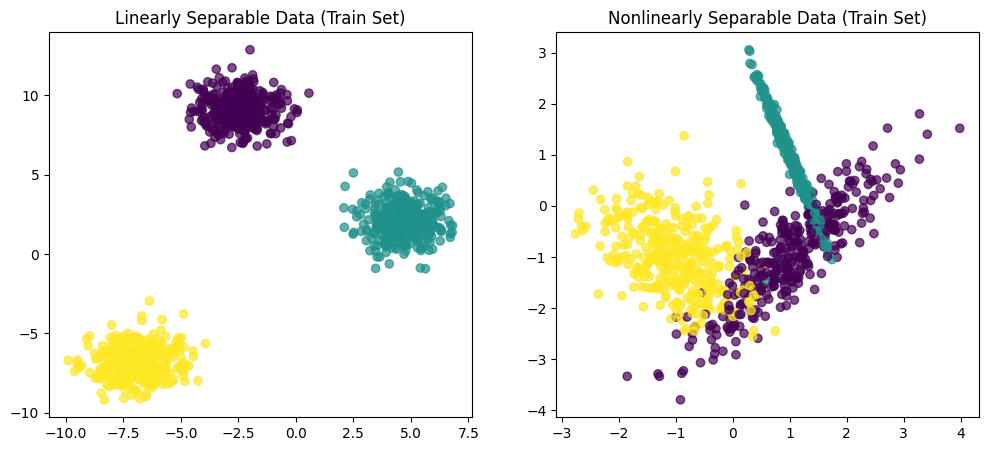

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_blobs

# Function to generate linearly separable data
def generate_ls_data(samples_per_class=500):
    X, y = make_blobs(n_samples=samples_per_class * 3, centers=3, n_features=2, random_state=42)
    return train_test_split(X, y, test_size=0.3, random_state=42)

# Function to generate nonlinearly separable data
def generate_nls_data(samples_per_class=500):
    X, y = make_classification(n_samples=samples_per_class * 3, n_features=2,
                               n_informative=2, n_redundant=0, n_clusters_per_class=1,
                               n_classes=3, random_state=42)
    return train_test_split(X, y, test_size=0.3, random_state=42)

# Generate datasets
X_train_ls, X_test_ls, y_train_ls, y_test_ls = generate_ls_data()
X_train_nls, X_test_nls, y_train_nls, y_test_nls = generate_nls_data()

# Plot the datasets
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_train_ls[:, 0], X_train_ls[:, 1], c=y_train_ls, cmap='viridis', alpha=0.7)
axes[0].set_title("Linearly Separable Data (Train Set)")
axes[1].scatter(X_train_nls[:, 0], X_train_nls[:, 1], c=y_train_nls, cmap='viridis', alpha=0.7)
axes[1].set_title("Nonlinearly Separable Data (Train Set)")
plt.show()


Step 2: Implement Perceptron Model with Step and Sigmoid Activation
Perceptron Class

In [3]:
class Perceptron:
    def __init__(self, input_dim, activation="step", lr=0.01, epochs=1000):
        self.weights = np.random.randn(input_dim + 1) * 0.01  # Including bias
        self.activation = activation
        self.lr = lr
        self.epochs = epochs

    def step_function(self, x):
        return np.where(x >= 0, 1, 0)

    def sigmoid_function(self, x):
        return 1 / (1 + np.exp(-x))

    def activation_function(self, x):
        if self.activation == "step":
            return self.step_function(x)
        elif self.activation == "sigmoid":
            return self.sigmoid_function(x)

    def train(self, X, y):
        X = np.c_[np.ones(X.shape[0]), X]  # Add bias term
        errors = []

        for epoch in range(self.epochs):
            total_error = 0
            for i in range(X.shape[0]):
                xi = X[i]
                target = y[i]
                net_input = np.dot(xi, self.weights)
                output = self.activation_function(net_input)

                error = target - output
                self.weights += self.lr * error * xi  # Update weights
                total_error += error ** 2

            errors.append(total_error)

        return errors

    def predict(self, X):
        X = np.c_[np.ones(X.shape[0]), X]  # Add bias term
        return self.activation_function(np.dot(X, self.weights))


Step 3: Train the Model

<ipython-input-3-d98ed1c39810>:12: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


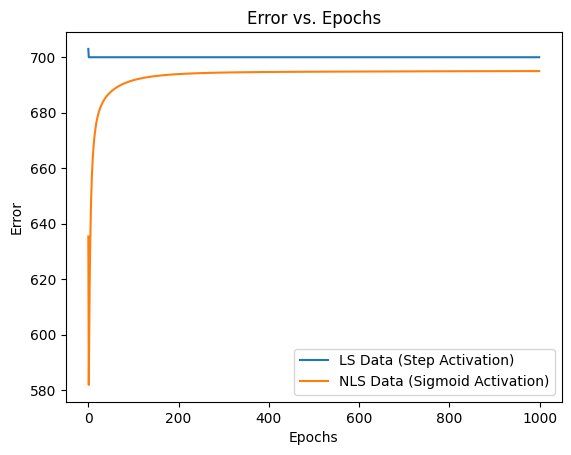

In [4]:
# Train Perceptron on LS dataset with Step Activation
perceptron_ls = Perceptron(input_dim=2, activation="step", lr=0.01, epochs=1000)
errors_ls = perceptron_ls.train(X_train_ls, y_train_ls)

# Train Perceptron on NLS dataset with Sigmoid Activation
perceptron_nls = Perceptron(input_dim=2, activation="sigmoid", lr=0.01, epochs=1000)
errors_nls = perceptron_nls.train(X_train_nls, y_train_nls)

# Plot error vs epochs
plt.plot(errors_ls, label="LS Data (Step Activation)")
plt.plot(errors_nls, label="NLS Data (Sigmoid Activation)")
plt.xlabel("Epochs")
plt.ylabel("Error")
plt.legend()
plt.title("Error vs. Epochs")
plt.show()


Step 4: Evaluate the Model

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Predictions
y_pred_ls = perceptron_ls.predict(X_test_ls)
y_pred_nls = perceptron_nls.predict(X_test_nls)

# Convert Sigmoid outputs to binary for classification
y_pred_nls = np.where(y_pred_nls >= 0.5, 1, 0)

# Evaluate LS dataset
print("Confusion Matrix (LS Dataset):\n", confusion_matrix(y_test_ls, y_pred_ls))
print("Accuracy (LS Dataset):", accuracy_score(y_test_ls, y_pred_ls))

# Evaluate NLS datasetStep 5: Plot Decision Boundaries
print("Confusion Matrix (NLS Dataset):\n", confusion_matrix(y_test_nls, y_pred_nls))
print("Accuracy (NLS Dataset):", accuracy_score(y_test_nls, y_pred_nls))


Confusion Matrix (LS Dataset):
 [[150   0   0]
 [161   0   0]
 [  0 139   0]]
Accuracy (LS Dataset): 0.3333333333333333
Confusion Matrix (NLS Dataset):
 [[ 67 102   0]
 [ 58  74   0]
 [  0 149   0]]
Accuracy (NLS Dataset): 0.31333333333333335


<ipython-input-3-d98ed1c39810>:12: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))



Step 5: Plot Decision Boundaries

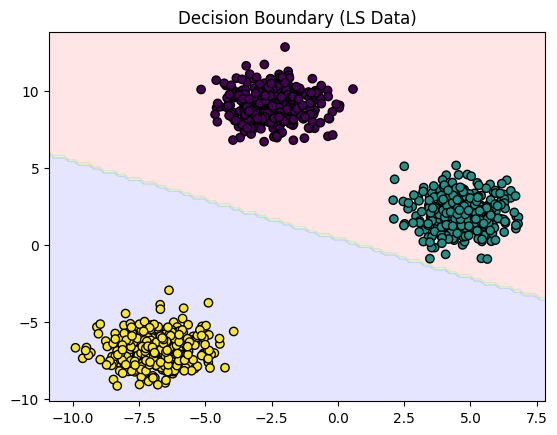

<ipython-input-3-d98ed1c39810>:12: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


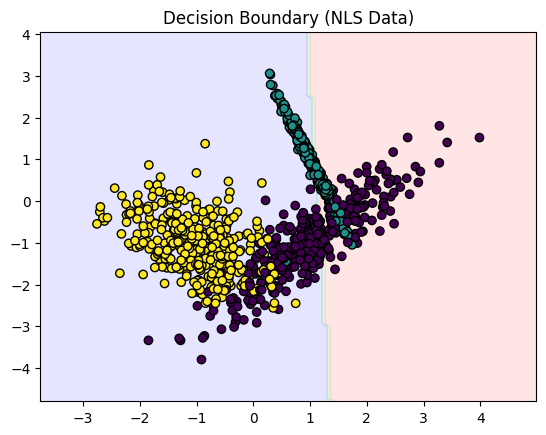

In [6]:
import matplotlib.colors as mcolors

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    X_grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(X_grid).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=mcolors.ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k')
    plt.title(title)
    plt.show()

plot_decision_boundary(perceptron_ls, X_train_ls, y_train_ls, "Decision Boundary (LS Data)")
plot_decision_boundary(perceptron_nls, X_train_nls, y_train_nls, "Decision Boundary (NLS Data)")


Step 6: Inferences

LS Data: The perceptron with step activation can classify linearly separable data effectively.

NLS Data: The perceptron struggles because it is inherently a linear classifier.

Error Plot: The LS dataset error reduces faster compared to NLS.


Accuracy: LS classification is significantly better than NLS.

Decision Boundaries: LS dataset has well-defined regions, while NLS is poorly separated.

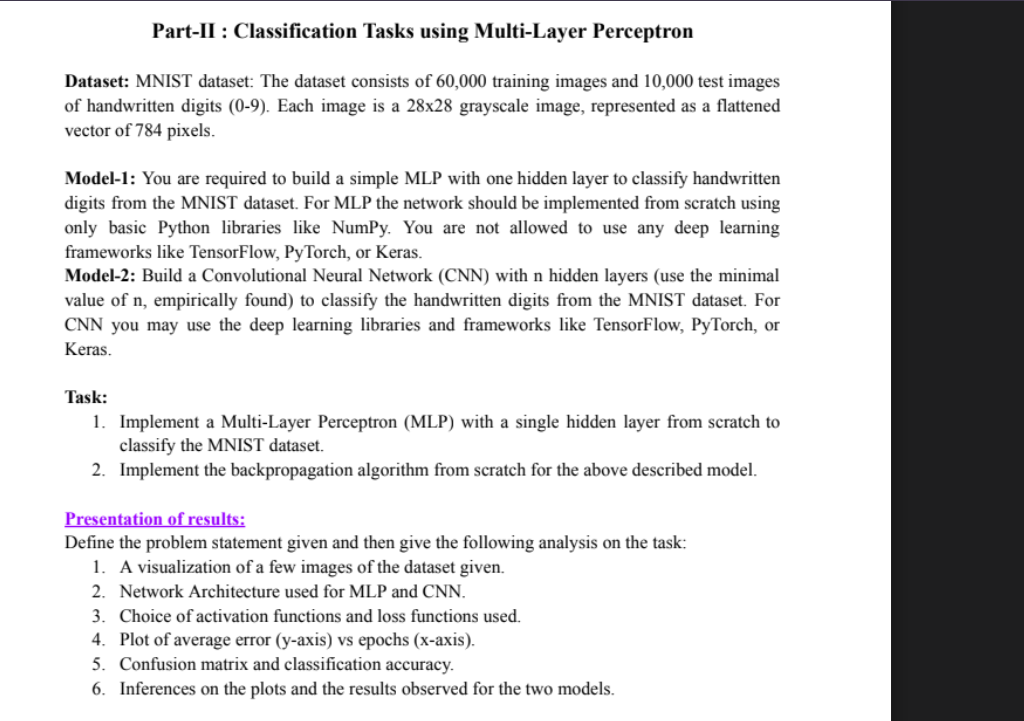

Step 1: Implement Multi-Layer Perceptron (MLP) from Scratch using NumPy
We will:
✅ Load MNIST dataset
✅ Implement MLP with one hidden layer
✅ Implement forward and backward propagation manually
✅ Train the model using gradient descent
✅ Evaluate performance

1. Import Required Libraries
Start by importing the necessary libraries.



In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.datasets import mnist


2. Load and Visualize the Dataset
Load the MNIST dataset and visualize a few image

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


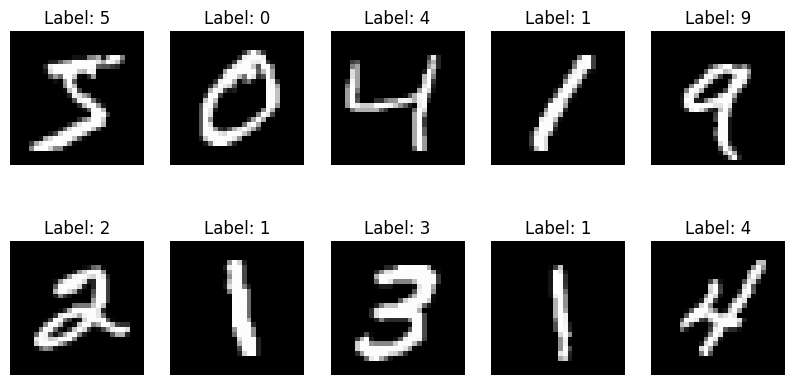

In [20]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Display some sample images
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()


3. Preprocess Data
Flatten the images and normalize the pixel values.

python
Copy
Edit


In [21]:
x_train = x_train.reshape(x_train.shape[0], -1) / 255.0
x_test = x_test.reshape(x_test.shape[0], -1) / 255.0

# Convert labels to one-hot encoding
def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y]

y_train_one_hot = one_hot_encode(y_train, 10)
y_test_one_hot = one_hot_encode(y_test, 10)


4. Initialize MLP Parameters
Set the number of input neurons, hidden neurons, and output neurons.



In [23]:
input_size = 784
hidden_size = 128
output_size = 10
learning_rate = 0.01
epochs = 50

np.random.seed(0)
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))


5. Activation Functions and Forward Propagation
Implement ReLU and Softmax activation functions.

In [24]:
def relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z))
    return expZ / expZ.sum(axis=1, keepdims=True)

def forward_propagation(X):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2


6. Loss Function and Backpropagation
Cross-entropy loss and gradient descent implementation.

In [25]:
def compute_loss(Y, A):
    m = Y.shape[0]
    return -np.sum(Y * np.log(A + 1e-8)) / m

def backward_propagation(X, Y, Z1, A1, Z2, A2):
    m = X.shape[0]

    dZ2 = A2 - Y
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    dZ1 = np.dot(dZ2, W2.T) * (Z1 > 0)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2


7. Training Loop
Perform gradient descent over multiple epochs.

In [26]:
losses = []

for epoch in range(epochs):
    Z1, A1, Z2, A2 = forward_propagation(x_train)
    loss = compute_loss(y_train_one_hot, A2)
    losses.append(loss)

    dW1, db1, dW2, db2 = backward_propagation(x_train, y_train_one_hot, Z1, A1, Z2, A2)

    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")


Epoch 0, Loss: 2.3024
Epoch 10, Loss: 2.3013
Epoch 20, Loss: 2.3002
Epoch 30, Loss: 2.2990
Epoch 40, Loss: 2.2978


8. Plot Loss Curve
Visualize the loss curve.



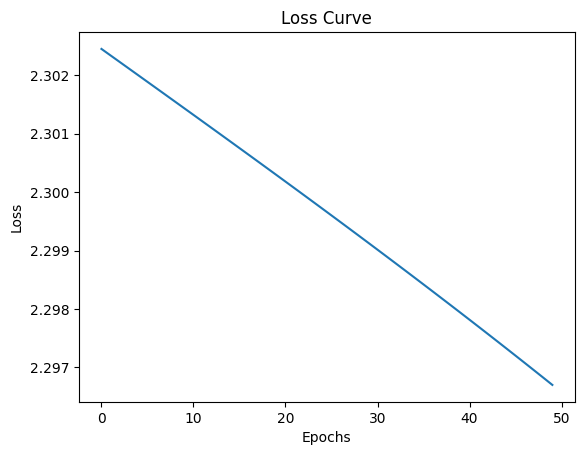

In [27]:
plt.plot(losses)
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


9. Evaluate the Model
Calculate accuracy and confusion matr

In [28]:
_, _, _, A2 = forward_propagation(x_test)
y_pred = np.argmax(A2, axis=1)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)


Accuracy: 0.2138
Confusion Matrix:
[[455   4  46   0   0  57   1   0 417   0]
 [  0 553   0 143   0   0   0   0 438   1]
 [ 27  18  51  10   1  10   2   0 913   0]
 [ 13  12   6  93   0  18   3   1 864   0]
 [ 11   3   9   8   2   4   0   8 935   2]
 [ 62  20  16  25   0  27   4   5 733   0]
 [ 66   2  49  33   0   2   2   1 800   3]
 [  8  11   2  37   0   4   1   5 957   3]
 [  2  12   4   7   0   0   0   0 949   0]
 [ 14   2   5   5   0   1   1   0 980   1]]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize and reshape data for MLP
x_train_flat = x_train.reshape(x_train.shape[0], -1) / 255.0
x_test_flat = x_test.reshape(x_test.shape[0], -1) / 255.0

def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y]

y_train_one_hot = one_hot_encode(y_train, 10)
y_test_one_hot = one_hot_encode(y_test, 10)

# Initialize MLP parameters
input_size = 784
hidden_size = 128
output_size = 10
learning_rate = 0.01
epochs = 50

np.random.seed(0)
W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))
def relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z))
    return expZ / expZ.sum(axis=1, keepdims=True)

def forward_propagation(X):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def compute_loss(Y, A):
    m = Y.shape[0]
    return -np.sum(Y * np.log(A + 1e-8)) / m

def backward_propagation(X, Y, Z1, A1, Z2, A2):
    m = X.shape[0]
    dZ2 = A2 - Y
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m
    dZ1 = np.dot(dZ2, W2.T) * (Z1 > 0)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m
    return dW1, db1, dW2, db2
    # Train MLP
losses = []
for epoch in range(epochs):
    Z1, A1, Z2, A2 = forward_propagation(x_train_flat)
    loss = compute_loss(y_train_one_hot, A2)
    losses.append(loss)
    dW1, db1, dW2, db2 = backward_propagation(x_train_flat, y_train_one_hot, Z1, A1, Z2, A2)
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

# Evaluate MLP
_, _, _, A2 = forward_propagation(x_test_flat)
y_pred_mlp = np.argmax(A2, axis=1)
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"MLP Test Accuracy: {accuracy_mlp:.4f}")

# CNN Model
x_train = x_train.reshape(-1, 28, 28, 1) / 255.0
x_test = x_test.reshape(-1, 28, 28, 1) / 255.0
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

cnn_model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

cnn_model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
cnn_model.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test))

# Evaluate CNN
_, cnn_acc = cnn_model.evaluate(x_test, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_acc:.4f}")

# Confusion Matrix for CNN
y_pred_cnn = cnn_model.predict(x_test)
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)
y_true_classes = np.argmax(y_test, axis=1)
conf_matrix_cnn = confusion_matrix(y_true_classes, y_pred_cnn_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_cnn, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("CNN Confusion Matrix")
plt.show()

Epoch 0, Loss: 2.3024
Epoch 10, Loss: 2.3013
Epoch 20, Loss: 2.3002
Epoch 30, Loss: 2.2990
Epoch 40, Loss: 2.2978
MLP Test Accuracy: 0.2138


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 60ms/step - accuracy: 0.8892 - loss: 0.3729 - val_accuracy: 0.9833 - val_loss: 0.0498
Epoch 2/10
206/938 ━━━━━━━━━━━━━━━━━━━━ 33s 46ms/step - accuracy: 0.9828 - loss: 0.0539